Import Library

In [2]:
import pandas as pd

Import data

In [3]:
df1 = pd.read_csv('for_supervised_raw.csv')
df1 = df1.drop('Cluster_ID' , axis = 1)

df2 = pd.read_csv('unsupervised_results.csv')

Merge data

In [4]:
df_final = pd.concat([df1, df2], axis=1)
df_final.head()

,Age,Profession,Sex,Province,S_Occasion,C_Occasion,C_Frequency,S_Frequency,S_Screentime,S_Time(weekday),S_Time(weekend),S_Usage(festival),row_id,Cluster_ID
0,23-29ปี,พนักงานบริษัทเอกชน,ชาย,กรุงเทพมหานคร,Instagram,ไม่ดื่มกาแฟ Ready to drink เลย,กาแฟสดคั่วบด เช่น ร้านกาแฟสด,5-6 ครั้ง/อาทิตย์,5-6 ชม./วัน,"05.00-8.59น., 18.00-21.59น., 22.01-4.59น.","05.00-8.59น., 9.00-17.59น., 18.00-21.59น., 22....",ใช้มากกว่าปกติ,0,-1
1,23-29ปี,พนักงานบริษัทเอกชน,หญิง,กรุงเทพมหานคร,LINE,ไม่ดื่มกาแฟ Ready to drink เลย,กาแฟสดคั่วบด เช่น ร้านกาแฟสด,ทุกวัน,มากกว่า 6 ชม./วัน,"18.00-21.59น., 22.01-4.59น.","9.00-17.59น., 18.00-21.59น., 22.01-4.59น.",ใช้มากกว่าปกติ,1,1
2,23-29ปี,พนักงานบริษัทเอกชน,หญิง,กรุงเทพมหานคร,LINE,ดื่มให้ไม่ง่วงในวันที่ทำงานดึก,กาแฟสดคั่วบด เช่น ร้านกาแฟสด,ทุกวัน,3-4 ชม./วัน,"9.00-17.59น., 18.00-21.59น., 22.01-4.59น.","9.00-17.59น., 18.00-21.59น., 22.01-4.59น.",ใช้น้อยกว่าปกติ,2,0
3,30-39ปี,ฟรีแลนซ์/อาชีพอิสระ,ชาย,กรุงเทพมหานคร,LINE,ไม่ดื่มกาแฟ Ready to drink เลย,แคปซูลกาแฟ,ทุกวัน,5-6 ชม./วัน,18.00-21.59น.,18.00-21.59น.,ใช้เท่าเดิม,3,1
4,23-29ปี,พนักงานบริษัทเอกชน,ชาย,กรุงเทพมหานคร,Facebook,ไม่ดื่มกาแฟ Ready to drink เลย,กาแฟสดคั่วบด เช่น ร้านกาแฟสด,ทุกวัน,3-4 ชม./วัน,"9.00-17.59น., 18.00-21.59น.","9.00-17.59น., 18.00-21.59น., 22.01-4.59น.",ใช้เท่าเดิม,4,1


In [13]:
# Export ไฟล์ CSV
# df_final.to_csv('eda_file.csv', index=False)
# print("Export Success!")

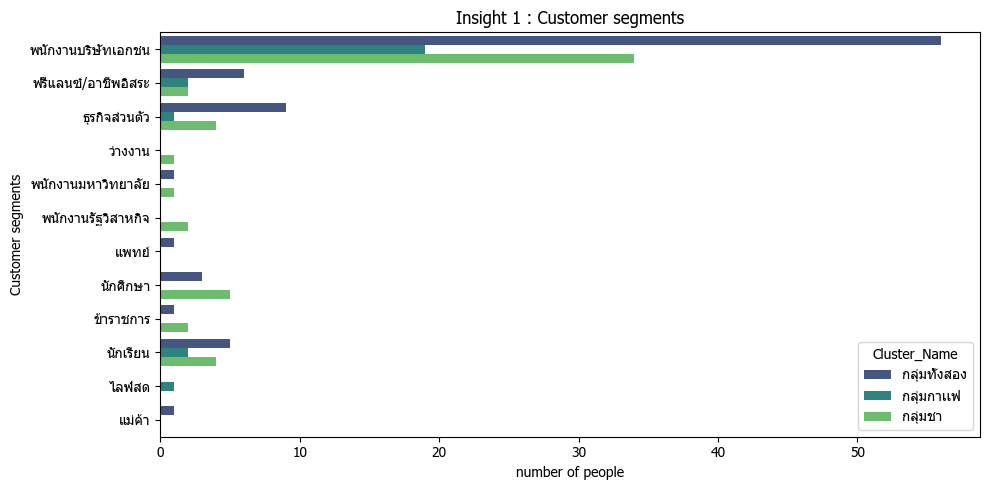

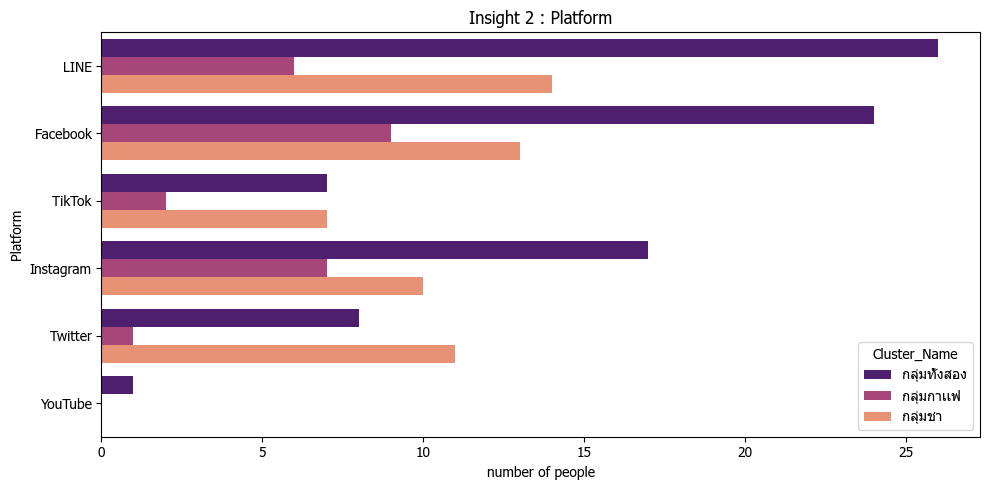

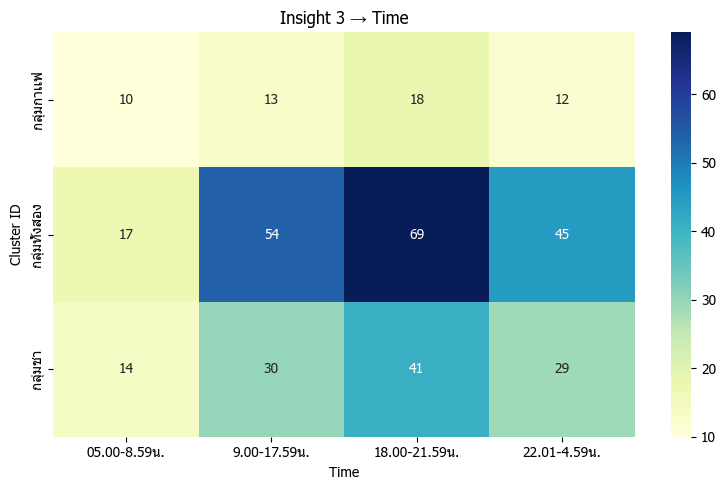

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

# =========================
# เตรียมข้อมูลหลัก
# =========================
cluster_labels = {
    0: 'กลุ่มกาเเฟ',
    1: 'กลุ่มทั้งสอง',
    2: 'กลุ่มชา'
}

df_plot = df_final[df_final['Cluster_ID'] != -1].copy()
df_plot['Cluster_Name'] = df_plot['Cluster_ID'].map(cluster_labels)

# =========================
# (1) Insight 1 → customer segments
# =========================
plt.figure(figsize=(10, 5))
sns.countplot(data=df_plot, y='Profession', hue='Cluster_Name', palette='viridis')
plt.title('Insight 1 : Customer segments')
plt.xlabel('number of people')
plt.ylabel('Customer segments')
plt.tight_layout()
plt.show()

# =========================
# (2) Insight 2 → Platform
# =========================
plt.figure(figsize=(10, 5))
sns.countplot(data=df_plot, y='S_Occasion', hue='Cluster_Name' ,palette='magma')
plt.title('Insight 2 : Platform')
plt.xlabel('number of people')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

# =========================
# (3) Insight 3 → Time (Heatmap)
# =========================
time_df = (
    df_plot.assign(Time_Slot=df_plot['S_Time(weekday)'].str.split(', '))
           .explode('Time_Slot')
)

time_order = ['05.00-8.59น.', '9.00-17.59น.', '18.00-21.59น.', '22.01-4.59น.']

time_matrix = pd.crosstab(
    time_df['Cluster_ID'],
    time_df['Time_Slot']
)[time_order]
time_matrix.index = time_matrix.index.map(cluster_labels)

plt.figure(figsize=(8, 5))
sns.heatmap(time_matrix,cmap='YlGnBu', annot=True, fmt='d')
plt.title('Insight 3 → Time')
plt.xlabel('Time')
plt.ylabel('Cluster ID')
plt.tight_layout()
plt.show()

Insight 1 : ใครคือกลุ่มเป้าหมายหลัก? (Customer Segments)

กลุ่มลูกค้าที่ใหญ่ที่สุดคือ "พนักงานบริษัทเอกชน" อย่างชัดเจน โดยแบ่งพฤติกรรมเป็น 3 กลุ่มหลัก (Clusters):

กลุ่มทั้งสอง (น้ำเงินเข้ม): เป็นกลุ่มที่ใหญ่ที่สุดในเกือบทุกอาชีพ โดยเฉพาะพนักงานบริษัท

กลุ่มชา (เขียวอ่อน): มีจำนวนรองลงมา โดยเฉพาะในกลุ่มพนักงานบริษัทและนักศึกษา/นักเรียน

กลุ่มกาแฟ (เขียวเข้ม): เป็นกลุ่มที่เล็กที่สุดในทุกช่วงอาชีพ

Insight 2 : ควรเข้าหาลูกค้าผ่านช่องทางไหน? (Platforms)

หากต้องการเข้าถึงกลุ่มเป้าหมายแต่ละ Cluster ควรเน้นแพลตฟอร์มที่ต่างกัน:

LINE & Facebook: คือช่องทางหลักที่เข้าถึงคนได้ทุกกลุ่ม โดยเฉพาะกลุ่ม "ทั้งคู่" จะหนาแน่นมากบน LINE (มากกว่า 25 คน)

Instagram: ได้รับความนิยมสูงในกลุ่ม "ทั้งคู่" และ "ชา"

Twitter: น่าสนใจตรงที่เป็นช่องทางที่กลุ่ม "ชา" ใช้งานมากกว่ากลุ่มอื่นอย่างเห็นได้ชัดเมื่อเทียบสัดส่วน (รองจากกลุ่มดื่มทั้งคู่เพียงเล็กน้อย)

YouTube: เป็นช่องทางที่มีการตอบรับน้อยที่สุดในเชิงสถิตินี้

Insight 3 : ควรยิงโฆษณาหรือขายช่วงเวลาไหน? (Time)

จาก Heatmap ของช่วงเวลา พบพฤติกรรมที่ชัดเจนดังนี้:

ช่วง Peak Time (18.00 - 21.59 น.): เป็นช่วงเวลาที่มีคนใช้งาน/สั่งซื้อสูงสุดในทุกกลุ่ม โดยเฉพาะกลุ่มทั้งสอง (69 คน) และกลุ่มชา (41 คน)

ช่วงกลางวัน (09.00 - 17.59 น.): เป็นช่วงรองลงมาที่กลุ่มทั้งสองให้ความสนใจสูง (54 คน)

ช่วงเช้ามืด (05.00 - 08.59 น.): เป็นช่วงที่เงียบเหงาที่สุดสำหรับทุกกลุ่มธุรกิจนี้

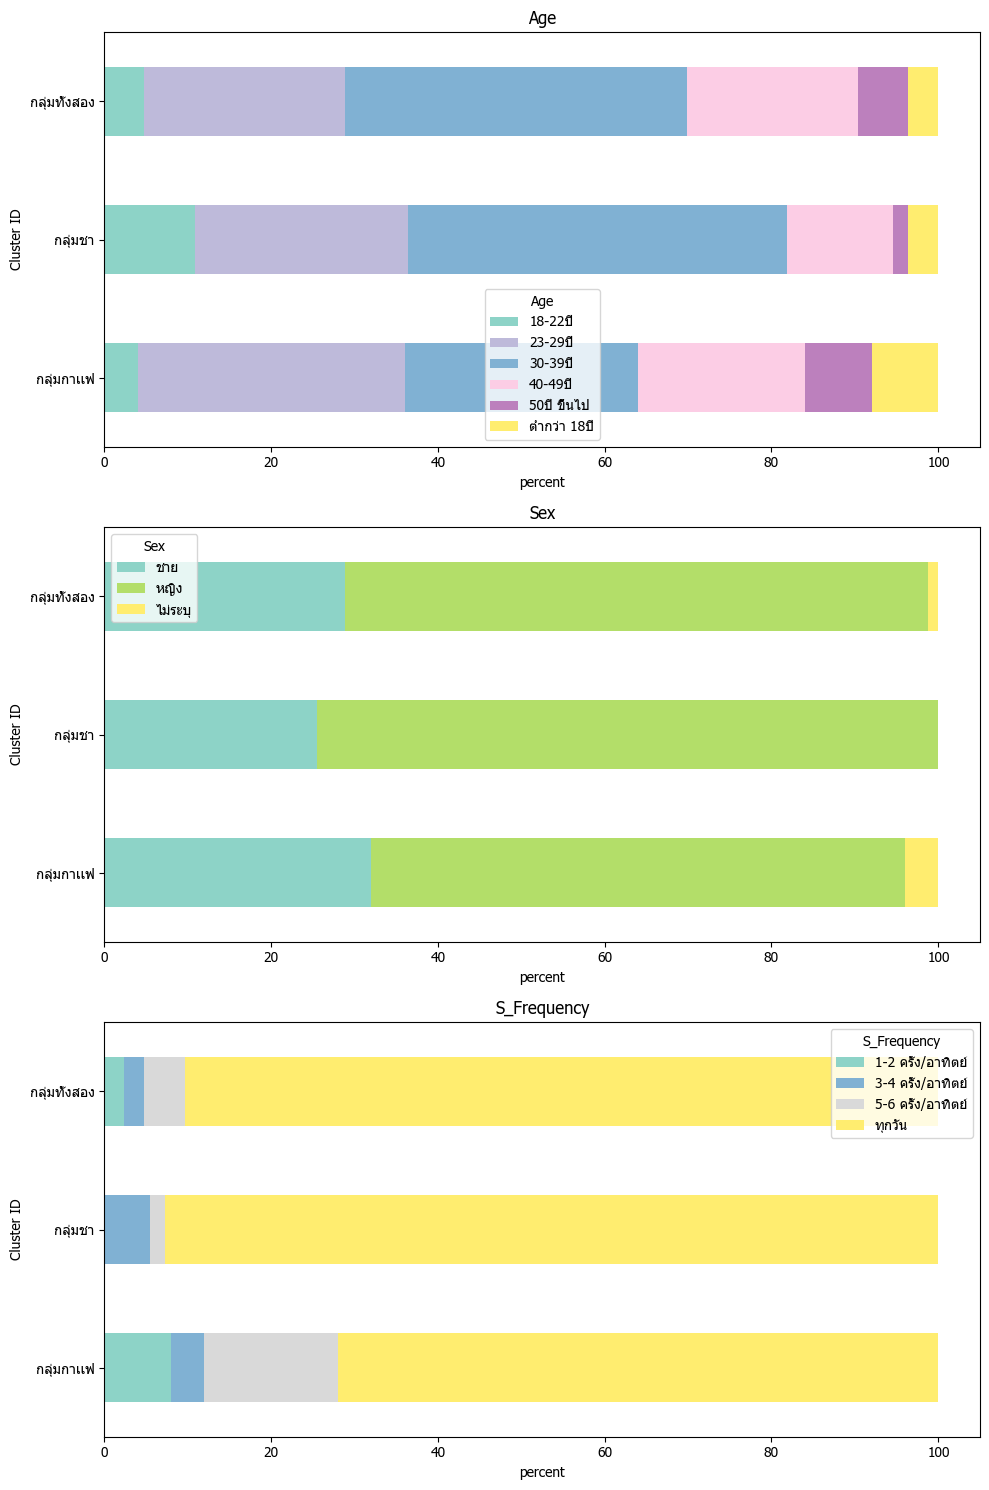

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# ฟังก์ชัน plot แบบสั้น
# =========================
def plot_pct(df, col, ax):
    pct = (
        df.groupby(['Cluster_Name', col])
          .size()
          .unstack(fill_value=0)
          .pipe(lambda x: x.div(x.sum(axis=1), axis=0) * 100)
    )
    
    pct.plot(kind='barh', stacked=True, ax=ax , colormap='Set3')
    ax.set_title(col)
    ax.set_xlabel('percent')
    ax.set_ylabel('Cluster ID')

# =========================
# สร้างกราฟ
# =========================
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

cols = ['Age', 'Sex', 'S_Frequency']

for ax, col in zip(axes, cols):
    plot_pct(df_plot, col, ax)

plt.tight_layout()
plt.show()

----- กลุ่มกาเเฟ หรือ Cluster 0 -----

ส่วนใหญ่มีอายุอยู่ที่ 23 - 29 สูงที่สุด เเละ เป็นผู้หญิงส่วนใหญ่

โดยชอบเล่น Social ทุกวัน

----- กลุ่มทั้งสอง หรือ Cluster 1 -----

ส่วนใหญ่มีอายุอยู่ที่ 30 - 39 สูงที่สุด เเละ เป็นผู้หญิงส่วนใหญ่

โดยชอบเล่น Social ทุกวัน

----- กลุ่มชา หรือ Cluster 2 -----

ส่วนใหญ่มีอายุอยู่ที่ 30 - 39 สูงที่สุด เเละ เป็นผู้หญิงส่วนใหญ่

โดยชอบเล่น Social ทุกวัน

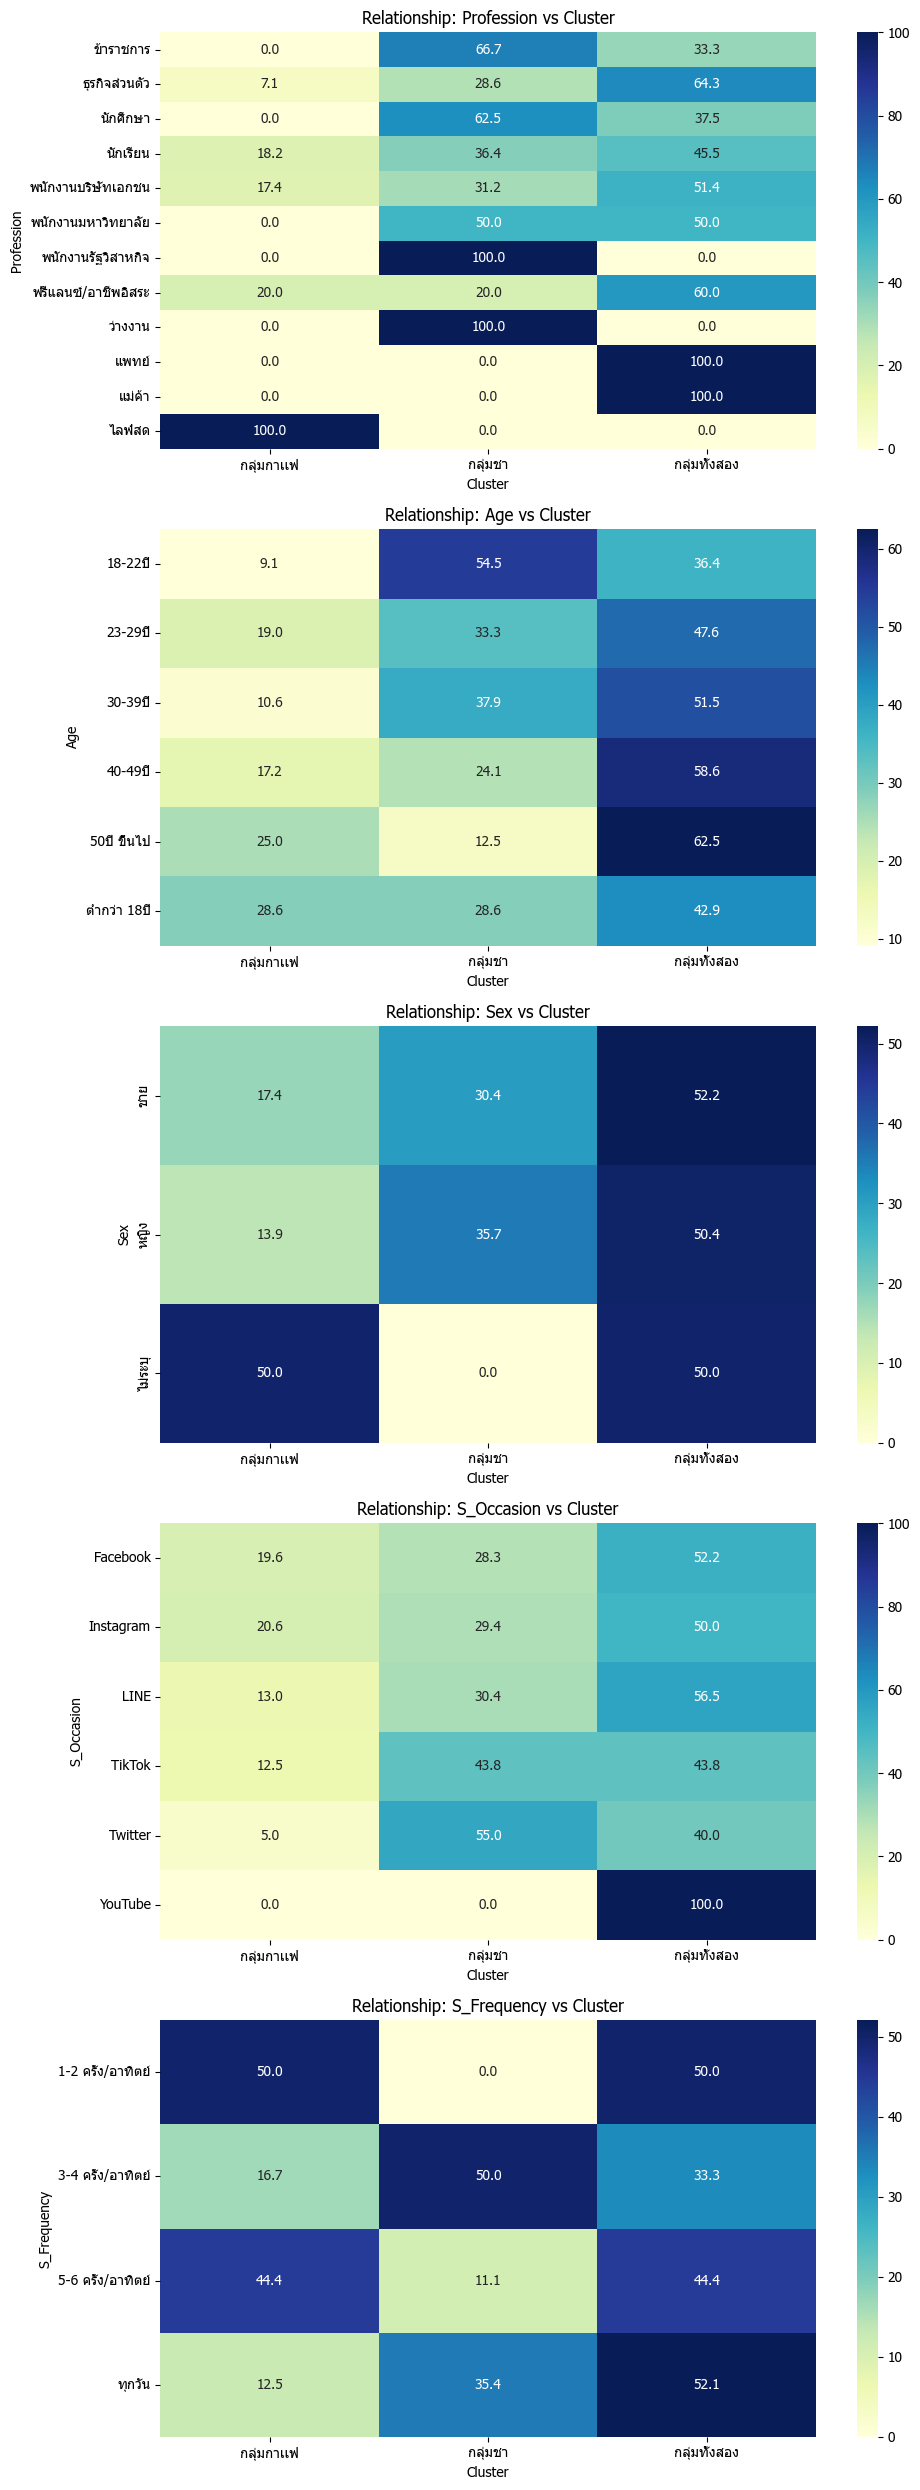

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


cols = ['Profession', 'Age', 'Sex', 'S_Occasion', 'S_Frequency']

# =========================
# สร้างกราฟ Heatmap หลายอัน (เรียงแนวตั้ง)
# =========================
plt.figure(figsize=(10, 5 * len(cols)))

for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)  # แบ่งพื้นที่กราฟ
    
    # สร้างตาราง %:
    # ในแต่ละค่า (เช่น เพศ/อาชีพ) → กระจายไปอยู่แต่ละ Cluster กี่ %
    ct = pd.crosstab(
        df_plot[col],
        df_plot['Cluster_Name'],
        normalize='index'   # normalize ตามแถว → ได้เป็น %
    ) * 100
    
    # วาด heatmap
    sns.heatmap(ct,cmap='YlGnBu', annot=True, fmt='.1f')
    
    # ตั้งชื่อแกน + title
    plt.title(f'Relationship: {col} vs Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

กราฟที่ 1 : 

กลุ่มกาเเฟ จะมีความสัมพันธ์กับกลุ่มลูกค้าประเภทไลฟ์สด

กลุ่มชา จะมีความสัมพันธ์กับกลุ่มลูกค้าประเภทฟรีแลนซ์ เเละ พนังงานรัฐวิสาหกิจ

กลุ่มทั้งสอง จะมีความสัมพันธ์กับกลุ่มลูกค้าประเภทเเพทย์ เเละ เเม่ค้า


กราฟที่ 2 :

กลุ่มกาเเฟ จะมีความสัมพันธ์กับกลุ่มลูกค้าที่มีอายุต่ำกว่า 18 ปี

กลุ่มชา จะมีความสัมพันธ์กับกลุ่มลูกค้าที่มีอายุ 18 - 22 ปี

กลุ่มทั้งสอง จะมีความสัมพันธ์กับกลุ่มลูกค้าที่มีอายุ 50 ปีขึ้นไป


กราฟที่ 3 :

กลุ่มกาเเฟ จะมีความสัมพันธ์กับกลุ่มลูกค้าที่ไม่ระบุตัวตน

กลุ่มชา จะมีความสัมพันธ์กับกลุ่มลูกค้าที่เป็นเพศหญิง

กลุ่มทั้งสอง จะมีความสัมพันธ์กับกลุ่มลูกค้าที่เป็นเพศชาย


กราฟที่ 4 :

กลุ่มกาเเฟ จะมีความสัมพันธ์กับกลุ่มลูกค้าที่ใช้งานบน Instagram

กลุ่มชา จะมีความสัมพันธ์กับกลุ่มลูกค้าที่ใช้งานบน Twitter

กลุ่มทั้งสอง จะมีความสัมพันธ์กับกลุ่มลูกค้าที่ใช้งานบน YouTube


กราฟที่ 5 :

กลุ่มกาเเฟ จะมีความสัมพันธ์กับกลุ่มลูกค้าที่ใช้งานบ่อยเเค่ 1 - 2 ครั้ง / อาทิตย์

กลุ่มชา จะมีความสัมพันธ์กับกลุ่มลูกค้าที่ใช้งานบ่อยเเค่ 3 - 4 ครั้ง / อาทิตย์

กลุ่มทั้งสอง จะมีความสัมพันธ์กับกลุ่มลูกค้าที่ใช้งานบ่อย ทุกวัน